# 02: Feature Engineering


| Feature                | What it captures biomechanically                                  |
|------------------------|--------------------------------------------------------------------|
| `mean`, `std`          | Resting offset and overall movement intensity                      |
| `rms`                  | Total energy of the motion                                         |
| `ptp` (peak-to-peak)   | Range of motion proxy                                              |
| `zcr`                  | Tempo proxy: how often the signal crosses its mean per second      |
| `skew`, `kurt`         | Asymmetry and 'spikiness' of the movement waveform                 |
| `dom_freq`             | Gait/movement cadence in Hz                                        |
| `spec_entropy`         | Smoothness vs jitter of the motion                                 |
| `energy_0_5hz`         | How concentrated the motion is in the slow, deliberate band        |

All of this is implemented in `src/features.py`. Below I demonstrate the pipeline on a single window so the transformation is visible.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG
from src import preprocessing as pp
from src import features as feat

## Load and segment

Window size is 100 samples (1 second at 100 Hz) with 50% overlap. That hits a good balance: long enough to span at least one full gait cycle for walking and several for running, short enough that windows are still locally stationary.

In [6]:
df = pp.load_data(CONFIG.DATA_PATHS["raw"] / "pamap2.csv")
df_clean = pp.clean(df)
df_interp = pp.interpolate_missing(df_clean)

X, y, subjects = pp.segment_windows(df_interp)
print(f"X.shape: {X.shape} (n_windows, window_size, n_channels)")
print(f"y.shape: {y.shape}")
print(f"Unique subjects: {np.unique(subjects)}")

x.shape: (38715, 100, 7) (n_windows, window_size, n_channels)
y.shape: (38715,)
Unique subjects: [101 102 103 104 105 106 107 108 109]


## A single window, end to end

Pick one window, plot it, and walk through the features it produces.

Window shape: (100, 7), Activity label: 1


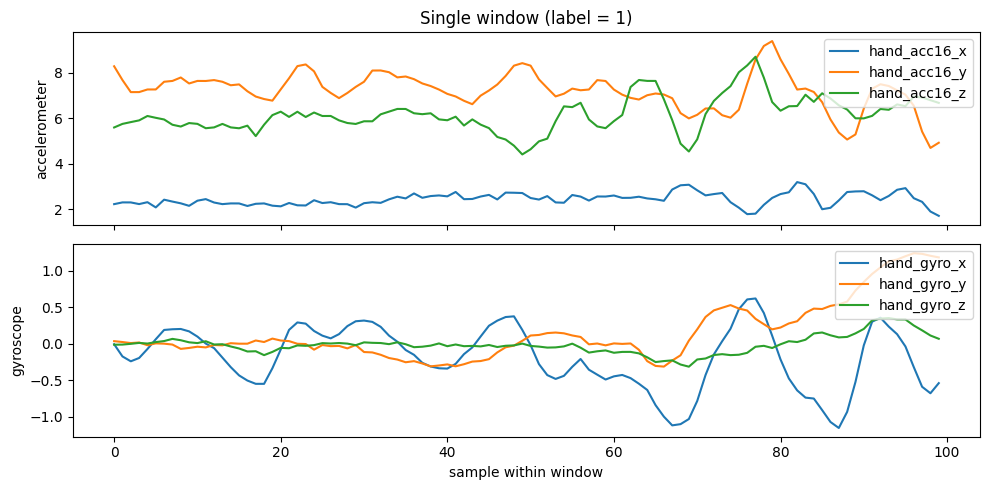

In [ ]:
idx = 0
window = X[idx]
label = y[idx]

print(f"Window shape: {window.shape}, Activity label: {label}")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Top subplot: accelerometer
for i, name in enumerate(['hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z']):
    axes[0].plot(window[:, i], label=name)
axes[0].legend(loc='upper right')
axes[0].set_title(f'Single window (label = {label})')
axes[0].set_ylabel('accelerometer')

# Bottom subplot: gyroscope
for i, name in enumerate(['hand_gyro_x', 'hand_gyro_y', 'hand_gyro_z']):
    axes[1].plot(window[:, 3 + i], label=name)   # +3 because gyro starts at column 3
axes[1].legend(loc='upper right')
axes[1].set_ylabel('gyroscope')
axes[1].set_xlabel('sample within window')

plt.tight_layout()
plt.show()

### Time-domain features for that window

In [9]:
time_feats = feat.extract_time_features(window, axis_names=CONFIG.FEATURE_COLS)
print("Time-domain features:")
print(pd.Series(time_feats).to_frame('value'))

Time-domain features:
                        value
hand_acc16_x_mean    2.429617
hand_acc16_x_std     0.276732
hand_acc16_x_rms     2.445326
hand_acc16_x_ptp     1.484970
hand_acc16_x_zcr     0.202020
hand_acc16_x_skew    0.133030
hand_acc16_x_kurt    0.431934
hand_acc16_y_mean    7.207710
hand_acc16_y_std     0.822744
hand_acc16_y_rms     7.254515
hand_acc16_y_ptp     4.699410
hand_acc16_y_zcr     0.151515
hand_acc16_y_skew   -0.594849
hand_acc16_y_kurt    1.392702
hand_acc16_z_mean    6.161272
hand_acc16_z_std     0.769552
hand_acc16_z_rms     6.209145
hand_acc16_z_ptp     4.296450
hand_acc16_z_zcr     0.151515
hand_acc16_z_skew    0.609971
hand_acc16_z_kurt    1.188357
hand_gyro_x_mean    -0.186630
hand_gyro_x_std      0.416555
hand_gyro_x_rms      0.456453
hand_gyro_x_ptp      1.772364
hand_gyro_x_zcr      0.111111
hand_gyro_x_skew    -0.393640
hand_gyro_x_kurt    -0.497619
hand_gyro_y_mean     0.151930
hand_gyro_y_std      0.395971
hand_gyro_y_rms      0.424118
hand_gyro_y_ptp   

### Frequency-domain features for that window

I'll plot the FFT alongside the extracted scalars so the dominant frequency value is easy to verify by eye.

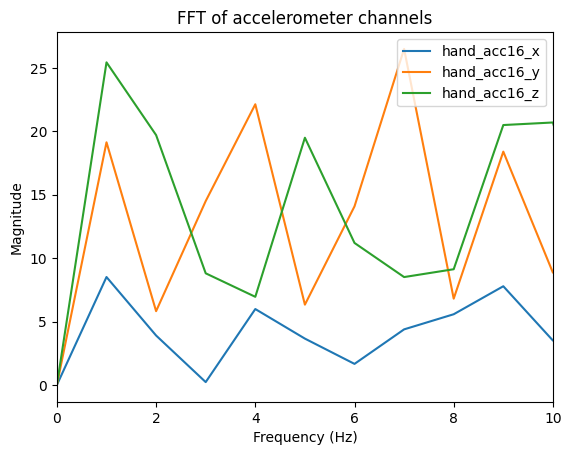

Frequency-domain features:
                                 value
hand_acc16_x_dom_freq         1.000000
hand_acc16_x_spec_entropy     4.128144
hand_acc16_x_energy_0_5hz   136.794020
hand_acc16_y_dom_freq         7.000000
hand_acc16_y_spec_entropy     3.923462
hand_acc16_y_energy_0_5hz  1140.175780
hand_acc16_z_dom_freq         1.000000
hand_acc16_z_spec_entropy     3.481259
hand_acc16_z_energy_0_5hz  1541.257565
hand_gyro_x_dom_freq          6.000000
hand_gyro_x_spec_entropy      2.965820
hand_gyro_x_energy_0_5hz    390.242715
hand_gyro_y_dom_freq          1.000000
hand_gyro_y_spec_entropy      2.527759
hand_gyro_y_energy_0_5hz    706.665977
hand_gyro_z_dom_freq          2.000000
hand_gyro_z_spec_entropy      2.333723
hand_gyro_z_energy_0_5hz     68.709709
heart_rate_dom_freq           1.000000
heart_rate_spec_entropy       1.322202
heart_rate_energy_0_5hz    1163.380368


In [10]:
freq_feats = feat.extract_freq_features(window,
                sample_rate=CONFIG.SAMPLE_RATE,
                axis_names=CONFIG.FEATURE_COLS)

freqs = np.fft.rfftfreq(window.shape[0], d=1.0/CONFIG.SAMPLE_RATE)
for i in range(3):  # accelerometer channels
    sig = window[:, i] - window[:, i].mean()  # zero-mean
    plt.plot(freqs, np.abs(np.fft.rfft(sig)), label=CONFIG.FEATURE_COLS[i])
plt.xlim(0, 10)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('FFT of accelerometer channels')
plt.legend()
plt.show()

print("Frequency-domain features:")
print(pd.Series(freq_feats).to_frame('value'))

## Build the full feature matrix

This is what gets fed to the classifier. Saving it to `data/processed/` so the modelling notebook doesn't need to repeat the work.

In [11]:
feature_df = feat.build_feature_matrix(X,
                      axis_names=CONFIG.FEATURE_COLS,
                      sample_rate=CONFIG.SAMPLE_RATE)
feature_df['label'] = y
feature_df['subject'] = subjects
print(f"Feature matrix shape: {feature_df.shape} (n_windows, n_features + 2)")
print(feature_df.head())

Feature matrix shape: (38715, 72) (n_windows, n_features + 2)
   hand_acc16_x_mean  hand_acc16_x_std  hand_acc16_x_rms  hand_acc16_x_ptp  \
0           2.429617          0.276732          2.445326           1.48497   
1           1.037049          1.657810          1.955456           5.40634   
2          -1.213772          1.131456          1.659348           4.59454   
3          -1.567099          0.715321          1.722639           3.88498   
4          -1.371397          0.690819          1.535565           4.46566   

   hand_acc16_x_zcr  hand_acc16_x_skew  hand_acc16_x_kurt  hand_acc16_y_mean  \
0          0.202020           0.133030           0.431934           7.207710   
1          0.010101          -0.382417          -1.520537           7.024636   
2          0.131313           1.006479           0.607105           8.159918   
3          0.141414           0.721155           1.447774           8.904961   
4          0.161616           0.026319           2.039071           9

In [12]:
out_path = CONFIG.DATA_PATHS['processed'] / 'features.parquet'
out_path.parent.mkdir(parents=True, exist_ok=True)
feature_df.to_parquet(out_path, index=False)
print(f"Feature matrix saved to: {out_path}")

Feature matrix saved to: C:\Users\John\github_projects\wearables-classifier\data\processed\features.parquet


## Quick sanity check: do features separate the classes?

I'll plot the distribution of one feature per class. If the medians line up exactly across all classes, that feature isn't pulling its weight.

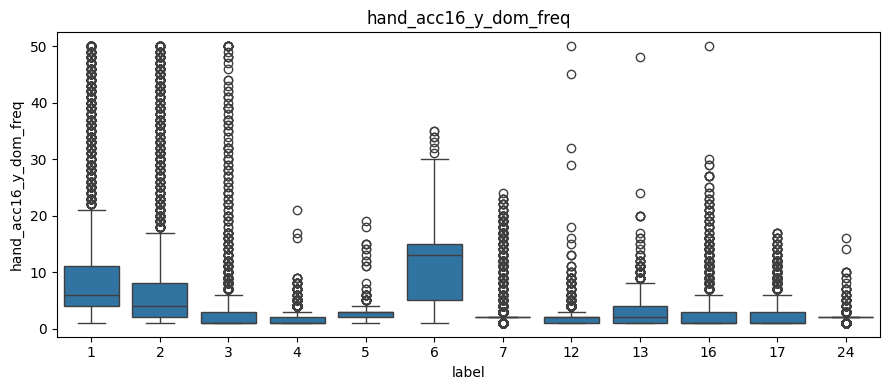

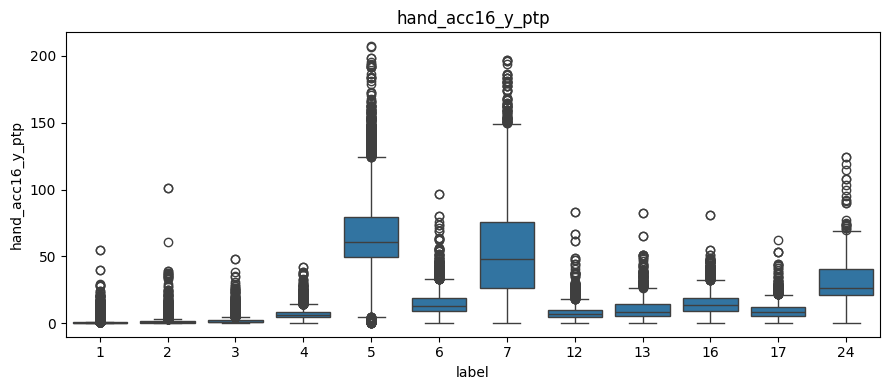

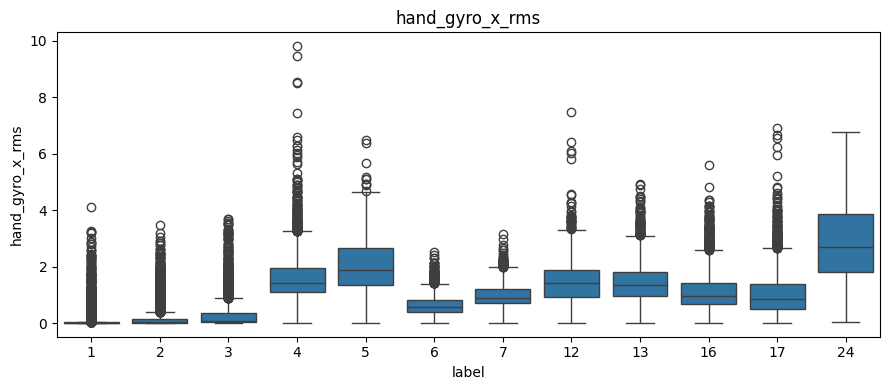

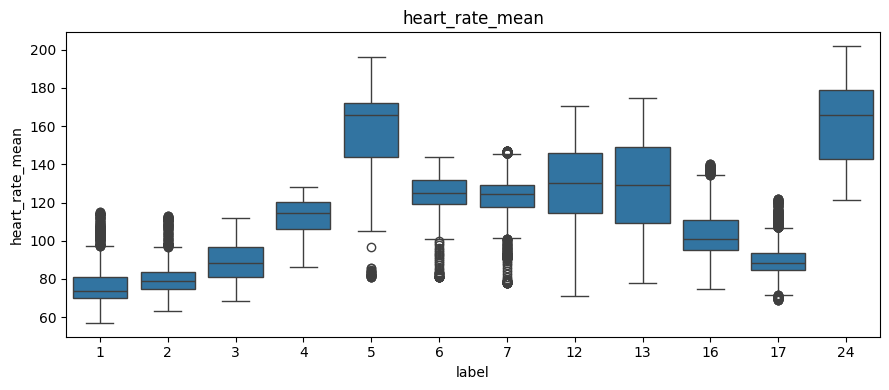

In [14]:
import seaborn as sns
for feat_to_inspect in ['hand_acc16_y_dom_freq',     # gait cadence
                        'hand_acc16_y_ptp',           # range of motion
                        'hand_gyro_x_rms',            # rotational energy
                        'heart_rate_mean']:           # intensity
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.boxplot(data=feature_df, x='label', y=feat_to_inspect, ax=ax)
    ax.set_title(feat_to_inspect)
    plt.tight_layout()
    plt.show()